In [2]:
import torch
print("GPU có sẵn không:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))


GPU có sẵn không: True
Tên GPU: Tesla T4


In [4]:
# Cài đặt các thư viện cần thiết cho NLP và đánh giá NER
!pip install -q transformers seqeval

# Import các thư viện vào notebook
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.optim import AdamW
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Đã import thành công toàn bộ thư viện cần thiết!")

Đã import thành công toàn bộ thư viện cần thiết!


In [6]:
train_path = '/train_dataset/train.txt'

print("--- 15 dòng đầu tiên của tập Train ---")
with open(train_path, 'r', encoding='utf-8') as f:
    for i in range(15):
        line = f.readline()
        if not line:
            break
        print(line, end='')

--- 15 dòng đầu tiên của tập Train ---
các O
khối B-ten_benh
u I-ten_benh
não I-ten_benh
xảy O
ra O
thường O
xuyên O
hơn O
ở O
người O
da O
trắng O
hơn O
là O


In [22]:
def load_conll_data(file_path):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    word, tag = parts[0], parts[1]
                    current_sentence.append((word, tag))
        if current_sentence:
            sentences.append(current_sentence)
    return sentences

# Đọc tập train
train_sentences = load_conll_data('/train_dataset/train.txt')

# 1. Thống kê tổng số câu
num_sentences = len(train_sentences)

# 2. Phân tích độ dài câu và thực thể
sentence_lengths = []
entity_lengths = []
all_tags = set()
tag_counts = {}

for sent in train_sentences:
    sentence_lengths.append(len(sent))

    # Trích xuất thực thể từ chuỗi B- / I-
    in_entity = False
    current_ent_len = 0

    for word, tag in sent:
        all_tags.add(tag)
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

        if tag.startswith('B-'):
            if in_entity:
                entity_lengths.append(current_ent_len)
            in_entity = True
            current_ent_len = 1
        elif tag.startswith('I-') and in_entity:
            current_ent_len += 1
        else:
            if in_entity:
                entity_lengths.append(current_ent_len)
                in_entity = False
                current_ent_len = 0
    if in_entity:
        entity_lengths.append(current_ent_len)

print(f"🔹 Tổng số câu trong tập Train: {num_sentences}")
print(f"🔹 Các loại nhãn xuất hiện: {sorted(list(all_tags))}")
print(f"🔹 Tổng số lượng nhãn O và thực thể: {tag_counts}")
print(f"📊 Độ dài câu (số từ): Min = {min(sentence_lengths)}, Max = {max(sentence_lengths)}, Trung bình = {sum(sentence_lengths)/num_sentences:.2f}")
if entity_lengths:
    print(f"📊 Độ dài thực thể (số từ): Min = {min(entity_lengths)}, Max = {max(entity_lengths)}, Trung bình = {sum(entity_lengths)/len(entity_lengths):.2f}")
else:
    print("Không tìm thấy thực thể nào được trích xuất (kiểm tra lại tiền tố nhãn).")
total_tokens = sum(tag_counts.values())
total_O = tag_counts.get('O', 0)
total_entities = total_tokens - total_O

# Tỷ lệ 1: Tổng thực thể trên toàn bộ token
entity_vs_total_pct = (total_entities / total_tokens) * 100

# Tỷ lệ 2: Tổng thực thể so với nhãn O
entity_vs_O_ratio = total_O / total_entities

print("\n" + "="*50)
print("📈 BẢNG CHỈ SỐ PHÂN TÍCH MẤT CÂN BẰNG (EDA):")
print(f"- Tổng số tokens toàn tập: {total_tokens}")
print(f"- Tổng số tokens nhãn 'O': {total_O} ({(total_O/total_tokens)*100:.2f}%)")
print(f"- Tổng số tokens thực thể (B- & I-): {total_entities} ({entity_vs_total_pct:.2f}%)")
print(f"👉 Mật độ thực thể trên tổng token: {entity_vs_total_pct:.2f}%")
print(f"👉 Tỷ lệ chênh lệch: Cứ khoảng {entity_vs_O_ratio:.1f} từ 'O' mới xuất hiện 1 từ thuộc thực thể y sinh.")
print("="*50)

🔹 Tổng số câu trong tập Train: 4573
🔹 Các loại nhãn xuất hiện: ['B-bien_phap_chan_doan', 'B-bien_phap_dieu_tri', 'B-nguyen_nhan_benh', 'B-ten_benh', 'B-trieu_chung_benh', 'I-bien_phap_chan_doan', 'I-bien_phap_dieu_tri', 'I-nguyen_nhan_benh', 'I-ten_benh', 'I-trieu_chung_benh', 'O']
🔹 Tổng số lượng nhãn O và thực thể: {'O': 127233, 'B-ten_benh': 5367, 'I-ten_benh': 13407, 'B-trieu_chung_benh': 2291, 'I-trieu_chung_benh': 4736, 'B-bien_phap_chan_doan': 861, 'I-bien_phap_chan_doan': 2506, 'B-bien_phap_dieu_tri': 1681, 'I-bien_phap_dieu_tri': 4676, 'B-nguyen_nhan_benh': 845, 'I-nguyen_nhan_benh': 3481}
📊 Độ dài câu (số từ): Min = 21, Max = 120, Trung bình = 36.54
📊 Độ dài thực thể (số từ): Min = 1, Max = 33, Trung bình = 3.61

📈 BẢNG CHỈ SỐ PHÂN TÍCH MẤT CÂN BẰNG (EDA):
- Tổng số tokens toàn tập: 167084
- Tổng số tokens nhãn 'O': 127233 (76.15%)
- Tổng số tokens thực thể (B- & I-): 39851 (23.85%)
👉 Mật độ thực thể trên tổng token: 23.85%
👉 Tỷ lệ chênh lệch: Cứ khoảng 3.2 từ 'O' mới xuất hi

In [21]:
train_sentences[0]

[('các', 'O'),
 ('khối', 'B-ten_benh'),
 ('u', 'I-ten_benh'),
 ('não', 'I-ten_benh'),
 ('xảy', 'O'),
 ('ra', 'O'),
 ('thường', 'O'),
 ('xuyên', 'O'),
 ('hơn', 'O'),
 ('ở', 'O'),
 ('người', 'O'),
 ('da', 'O'),
 ('trắng', 'O'),
 ('hơn', 'O'),
 ('là', 'O'),
 ('ở', 'O'),
 ('người', 'O'),
 ('của', 'O'),
 ('các', 'O'),
 ('chủng', 'O'),
 ('tộc', 'O'),
 ('khác', 'O'),
 ('.', 'O')]

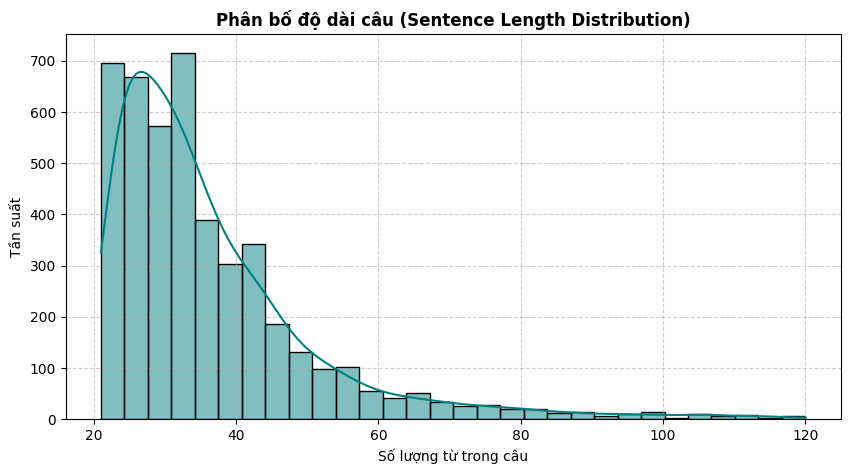

/tmp/ipykernel_1244/3556253035.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(tags), palette='viridis')


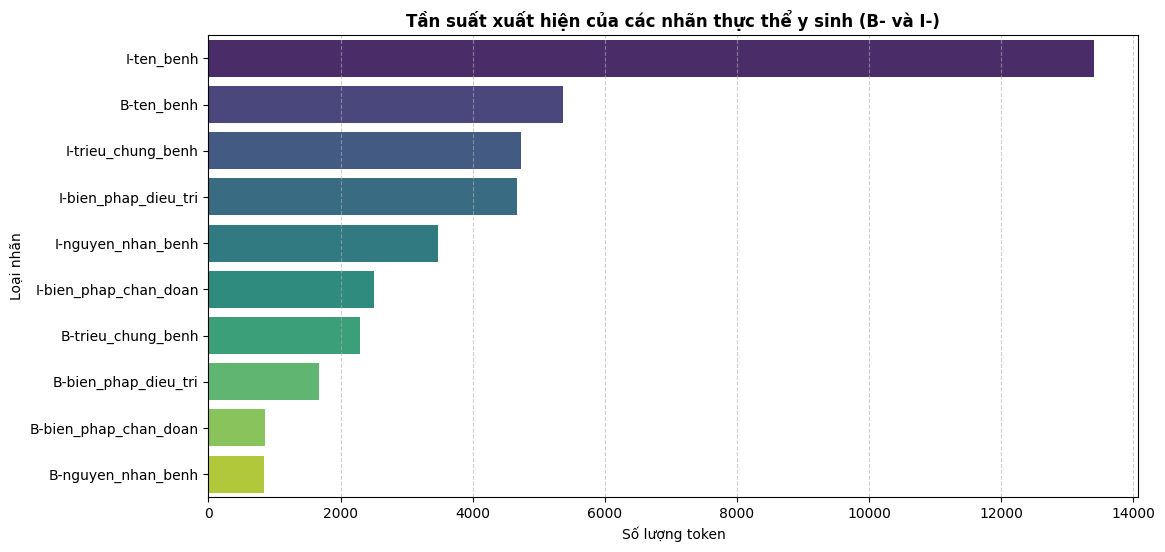

In [15]:
# 1. Vẽ biểu đồ phân bố độ dài câu
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=30, kde=True, color='teal')
plt.title('Phân bố độ dài câu (Sentence Length Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng từ trong câu', fontsize=10)
plt.ylabel('Tần suất', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Thống kê và vẽ biểu đồ tần suất các loại nhãn thực thể (không tính nhãn O để dễ quan sát)
entity_tag_counts = {k: v for k, v in tag_counts.items() if k != 'O'}
sorted_tags = sorted(entity_tag_counts.items(), key=lambda x: x[1], reverse=True)
tags, counts = zip(*sorted_tags)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(tags), palette='viridis')
plt.title('Tần suất xuất hiện của các nhãn thực thể y sinh (B- và I-)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng token', fontsize=10)
plt.ylabel('Loại nhãn', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

🎯 BÁCH PHÂN VỊ ĐỘ DÀI THỰC THỂ (ENTITY LENGTH PERCENTILES):
- P50 (Trung vị): 3 từ
- P90 (90% thực thể có độ dài <=): 6 từ
- P95 (95% thực thể có độ dài <=): 8 từ
- P99 (99% thực thể có độ dài <=): 15 từ
- Giá trị Max: 33 từ


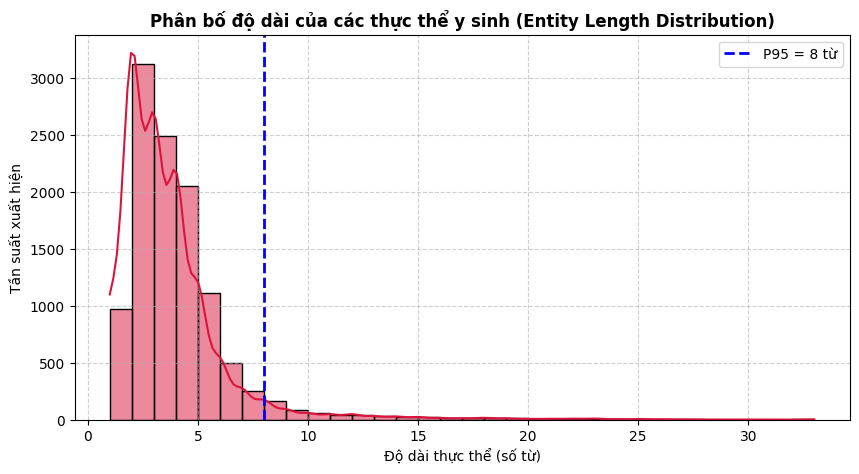

In [24]:
import numpy as np

# Tính các mốc bách phân vị (Percentiles) của độ dài thực thể
p50 = np.percentile(entity_lengths, 50)
p90 = np.percentile(entity_lengths, 90)
p95 = np.percentile(entity_lengths, 95)
p99 = np.percentile(entity_lengths, 99)

print("="*50)
print("🎯 BÁCH PHÂN VỊ ĐỘ DÀI THỰC THỂ (ENTITY LENGTH PERCENTILES):")
print(f"- P50 (Trung vị): {p50:.0f} từ")
print(f"- P90 (90% thực thể có độ dài <=): {p90:.0f} từ")
print(f"- P95 (95% thực thể có độ dài <=): {p95:.0f} từ")
print(f"- P99 (99% thực thể có độ dài <=): {p99:.0f} từ")
print(f"- Giá trị Max: {max(entity_lengths)} từ")
print("="*50)

# Vẽ biểu đồ phân bố độ dài thực thể
plt.figure(figsize=(10, 5))
sns.histplot(entity_lengths, bins=range(1, max(entity_lengths) + 1), color='crimson', kde=True)
plt.axvline(p95, color='blue', linestyle='--', linewidth=2, label=f'P95 = {p95:.0f} từ')
plt.title('Phân bố độ dài của các thực thể y sinh (Entity Length Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Độ dài thực thể (số từ)', fontsize=10)
plt.ylabel('Tần suất xuất hiện', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


🎯 BÁCH PHÂN VỊ ĐỘ DÀI CÂU (SENTENCE LENGTH PERCENTILES):
- P50 (Trung vị): 32 từ
- P90 (90% câu có độ dài <=): 54 từ
- P95 (95% câu có độ dài <=): 67 từ
- P99 (99% câu có độ dài <=): 99 từ
- Giá trị Max: 120 từ


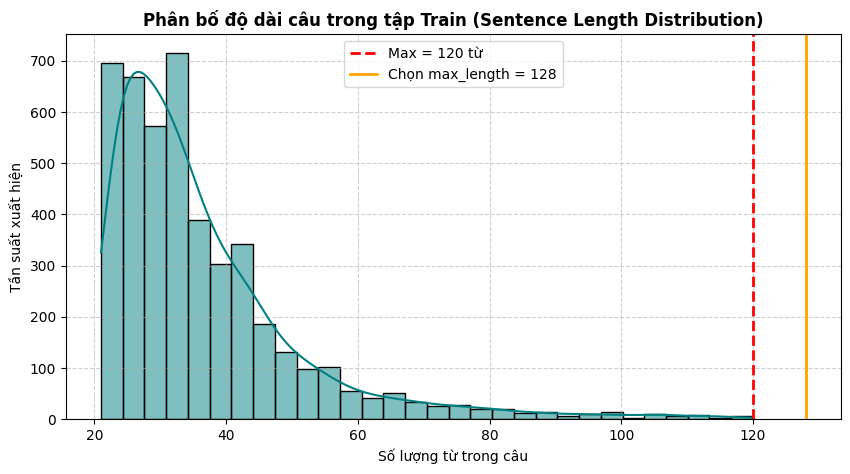

In [25]:
# Tính các mốc bách phân vị của độ dài câu
s_p50 = np.percentile(sentence_lengths, 50)
s_p90 = np.percentile(sentence_lengths, 90)
s_p95 = np.percentile(sentence_lengths, 95)
s_p99 = np.percentile(sentence_lengths, 99)
s_max = max(sentence_lengths)

print("="*50)
print("🎯 BÁCH PHÂN VỊ ĐỘ DÀI CÂU (SENTENCE LENGTH PERCENTILES):")
print(f"- P50 (Trung vị): {s_p50:.0f} từ")
print(f"- P90 (90% câu có độ dài <=): {s_p90:.0f} từ")
print(f"- P95 (95% câu có độ dài <=): {s_p95:.0f} từ")
print(f"- P99 (99% câu có độ dài <=): {s_p99:.0f} từ")
print(f"- Giá trị Max: {s_max} từ")
print("="*50)

# Vẽ biểu đồ phân bố độ dài câu
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=30, color='teal', kde=True)
plt.axvline(s_max, color='red', linestyle='--', linewidth=2, label=f'Max = {s_max} từ')
plt.axvline(128, color='orange', linestyle='-', linewidth=2, label='Chọn max_length = 128')
plt.title('Phân bố độ dài câu trong tập Train (Sentence Length Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng từ trong câu', fontsize=10)
plt.ylabel('Tần suất xuất hiện', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- đa số các thực thể đều có độ dài nhỏ từ 1-4 một số rất ít có độ dài lớn phân bố tập trung ở vùng đầu nên chọn

- cũng như phân bổ độ dài câu cũng phân bố tập trung ở vùng đầu

🎯 MẬT ĐỘ THỰC THỂ TRONG CÂU (ENTITIES PER SENTENCE):
- Số thực thể ít nhất trong 1 câu: 1
- Số thực thể nhiều nhất trong 1 câu: 20
- Trung bình số thực thể / câu: 2.42
🎯 ĐỘ DÀI THỰC THỂ THEO TỪNG LOẠI NHÃN (SỐ TỪ):
- Nhãn [ten_benh]: Min = 1, Max = 11, Trung bình = 3.50
- Nhãn [trieu_chung_benh]: Min = 1, Max = 33, Trung bình = 3.07
- Nhãn [bien_phap_chan_doan]: Min = 1, Max = 33, Trung bình = 3.91
- Nhãn [bien_phap_dieu_tri]: Min = 1, Max = 27, Trung bình = 3.78
- Nhãn [nguyen_nhan_benh]: Min = 1, Max = 31, Trung bình = 5.12


/tmp/ipykernel_1244/559798766.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Độ dài (số từ)', y='Loại nhãn', data=df_plot, palette='Set2')


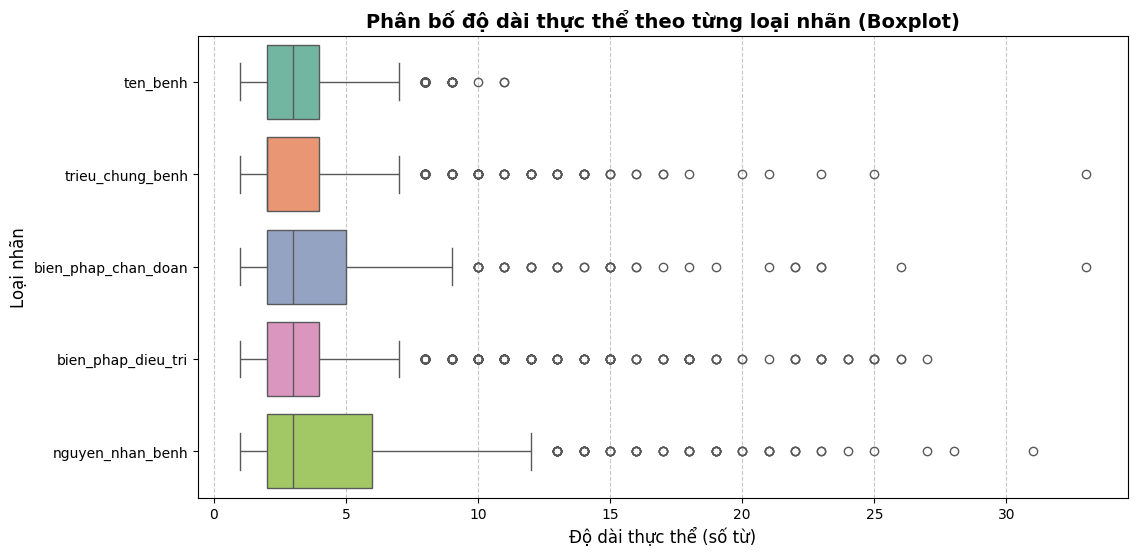

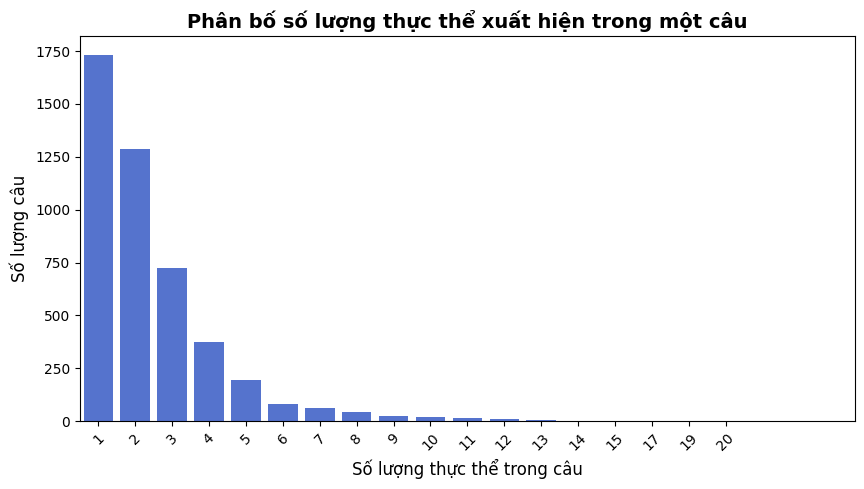

In [26]:
'''phân tích về số lượng thể thực theo câu, tỉ lệ của độ dài các loại thực thể theo câu
   phân tích độ dài thực thể theo từng loại tags '''
from collections import defaultdict

# 1. Khởi tạo biến lưu trữ
entities_per_sentence = []
entity_lengths_by_type = defaultdict(list)

# 2. Quét lại tập train để gom nhóm dữ liệu theo từng câu và từng loại nhãn
for sent in train_sentences:
    ent_count = 0
    in_entity = False
    current_ent_len = 0
    current_ent_type = ""

    for word, tag in sent:
        if tag.startswith('B-'):
            ent_count += 1
            if in_entity:
                entity_lengths_by_type[current_ent_type].append(current_ent_len)
            in_entity = True
            current_ent_len = 1
            current_ent_type = tag[2:] # Lấy tên nhãn bỏ đi tiền tố 'B-'
        elif tag.startswith('I-') and in_entity and tag[2:] == current_ent_type:
            current_ent_len += 1
        else:
            if in_entity:
                entity_lengths_by_type[current_ent_type].append(current_ent_len)
                in_entity = False
                current_ent_len = 0

    if in_entity:
        entity_lengths_by_type[current_ent_type].append(current_ent_len)

    entities_per_sentence.append(ent_count)

# 3. In thống kê số lượng thực thể trên mỗi câu
print("="*50)
print("🎯 MẬT ĐỘ THỰC THỂ TRONG CÂU (ENTITIES PER SENTENCE):")
print(f"- Số thực thể ít nhất trong 1 câu: {min(entities_per_sentence)}")
print(f"- Số thực thể nhiều nhất trong 1 câu: {max(entities_per_sentence)}")
print(f"- Trung bình số thực thể / câu: {sum(entities_per_sentence)/len(entities_per_sentence):.2f}")
print("="*50)

# 4. In thống kê độ dài thực thể theo từng loại nhãn
print("🎯 ĐỘ DÀI THỰC THỂ THEO TỪNG LOẠI NHÃN (SỐ TỪ):")
for ent_type, lengths in entity_lengths_by_type.items():
    print(f"- Nhãn [{ent_type}]: Min = {min(lengths)}, Max = {max(lengths)}, Trung bình = {sum(lengths)/len(lengths):.2f}")
print("="*50)

# 5. Vẽ biểu đồ Boxplot phân bố độ dài theo từng loại nhãn
plt.figure(figsize=(12, 6))
# Chuyển đổi dict sang dạng danh sách phẳng để đưa vào Seaborn
data_for_plot = []
for ent_type, lengths in entity_lengths_by_type.items():
    for length in lengths:
        data_for_plot.append({'Loại nhãn': ent_type, 'Độ dài (số từ)': length})
df_plot = pd.DataFrame(data_for_plot)

sns.boxplot(x='Độ dài (số từ)', y='Loại nhãn', data=df_plot, palette='Set2')
plt.title('Phân bố độ dài thực thể theo từng loại nhãn (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Độ dài thực thể (số từ)', fontsize=12)
plt.ylabel('Loại nhãn', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Vẽ biểu đồ mật độ thực thể trên câu
plt.figure(figsize=(10, 5))
sns.countplot(x=entities_per_sentence, color='royalblue')
plt.title('Phân bố số lượng thực thể xuất hiện trong một câu', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng thực thể trong câu', fontsize=12)
plt.ylabel('Số lượng câu', fontsize=12)
# Chỉ hiển thị các tick hợp lý nếu trục x quá dày
plt.xticks(rotation=45)
plt.xlim(-0.5, min(max(entities_per_sentence), 30) + 0.5) # Giới hạn hiển thị trục x cho dễ nhìn
plt.show()

In [27]:
from collections import Counter

# Rút trích các chuỗi thực thể hoàn chỉnh
entity_strings = defaultdict(list)

for sent in train_sentences:
    in_entity = False
    current_ent = []
    current_type = ""

    for word, tag in sent:
        if tag.startswith('B-'):
            if in_entity:
                entity_strings[current_type].append(" ".join(current_ent).lower())
            in_entity = True
            current_ent = [word]
            current_type = tag[2:]
        elif tag.startswith('I-') and in_entity and tag[2:] == current_type:
            current_ent.append(word)
        else:
            if in_entity:
                entity_strings[current_type].append(" ".join(current_ent).lower())
                in_entity = False
                current_ent = []

    if in_entity:
        entity_strings[current_type].append(" ".join(current_ent).lower())

# In Top 5 thực thể phổ biến nhất cho mỗi loại
print("="*50)
print("🔥 TOP 5 CỤM TỪ PHỔ BIẾN NHẤT THEO TỪNG LOẠI NHÃN:")
for ent_type, strings in entity_strings.items():
    top_5 = Counter(strings).most_common(5)
    print(f"\n🔹 Nhãn [{ent_type}]:")
    for string, count in top_5:
        print(f"   - '{string}': {count} lần")
print("="*50)

🔥 TOP 5 CỤM TỪ PHỔ BIẾN NHẤT THEO TỪNG LOẠI NHÃN:

🔹 Nhãn [ten_benh]:
   - 'ung thư': 146 lần
   - 'suy tim': 75 lần
   - 'ung thư đại tràng': 57 lần
   - 'rung nhĩ': 56 lần
   - 'bệnh ung thư': 51 lần

🔹 Nhãn [trieu_chung_benh]:
   - 'đau': 58 lần
   - 'sốt': 52 lần
   - 'đau bụng': 48 lần
   - 'khó thở': 48 lần
   - 'mệt mỏi': 40 lần

🔹 Nhãn [bien_phap_chan_doan]:
   - 'nội soi': 45 lần
   - 'siêu âm': 40 lần
   - 'sinh thiết': 32 lần
   - 'xét nghiệm máu': 30 lần
   - 'mri': 25 lần

🔹 Nhãn [bien_phap_dieu_tri]:
   - 'phẫu thuật': 173 lần
   - 'xạ trị': 73 lần
   - 'kháng sinh': 29 lần
   - 'hóa trị': 28 lần
   - 'thuốc kháng sinh': 25 lần

🔹 Nhãn [nguyen_nhan_benh]:
   - 'vi khuẩn': 33 lần
   - 'virus': 15 lần
   - 'cục máu đông': 14 lần
   - 'ho': 13 lần
   - 'h . pylori': 12 lần


In [28]:
import itertools

# Đếm số lần các loại nhãn cùng xuất hiện trong một câu
co_occurrence_counts = Counter()

for sent in train_sentences:
    # Lấy tập hợp các loại thực thể có trong câu
    types_in_sent = set()
    for word, tag in sent:
        if tag.startswith('B-'):
            types_in_sent.add(tag[2:])

    # Tạo các cặp đồng xuất hiện
    if len(types_in_sent) > 1:
        pairs = itertools.combinations(sorted(list(types_in_sent)), 2)
        co_occurrence_counts.update(pairs)

print("\n🤝 TOP CÁC CẶP THỰC THỂ THƯỜNG XUẤT HIỆN CÙNG NHAU TRONG 1 CÂU:")
for pair, count in co_occurrence_counts.most_common():
    print(f"- {pair[0]} & {pair[1]}: {count} câu")


🤝 TOP CÁC CẶP THỰC THỂ THƯỜNG XUẤT HIỆN CÙNG NHAU TRONG 1 CÂU:
- ten_benh & trieu_chung_benh: 515 câu
- bien_phap_dieu_tri & ten_benh: 412 câu
- nguyen_nhan_benh & ten_benh: 332 câu
- bien_phap_chan_doan & ten_benh: 222 câu
- bien_phap_dieu_tri & trieu_chung_benh: 102 câu
- nguyen_nhan_benh & trieu_chung_benh: 83 câu
- bien_phap_dieu_tri & nguyen_nhan_benh: 41 câu
- bien_phap_chan_doan & trieu_chung_benh: 40 câu
- bien_phap_chan_doan & bien_phap_dieu_tri: 32 câu
- bien_phap_chan_doan & nguyen_nhan_benh: 21 câu


In [29]:
# Lập bản đồ: Từ -> Các nhãn đã được gán
word_to_tags = defaultdict(set)
for sent in train_sentences:
    for word, tag in sent:
        word_to_tags[word.lower()].add(tag)

# Tìm các từ bị gán nhiều hơn 1 loại nhãn (loại bỏ phân biệt B- và I-)
ambiguous_words = {}
for word, tags in word_to_tags.items():
    # Chuẩn hóa nhãn (B-ten_benh và I-ten_benh coi là 1 loại)
    base_tags = set(t[2:] if t != 'O' else 'O' for t in tags)
    if len(base_tags) > 1:
        ambiguous_words[word] = base_tags

print(f"\n⚠️ PHÁT HIỆN XUNG ĐỘT NHÃN (LABEL AMBIGUITY):")
print(f"- Có {len(ambiguous_words)} từ bị gán mâu thuẫn (lúc thì nhãn này, lúc nhãn khác).")
print("- Top 10 từ gây nhiễu nhất (Ví dụ):")
for i, (word, tags) in enumerate(list(ambiguous_words.items())[:10]):
    print(f"  + Từ '{word}': được gán các nhãn {tags}")


⚠️ PHÁT HIỆN XUNG ĐỘT NHÃN (LABEL AMBIGUITY):
- Có 1589 từ bị gán mâu thuẫn (lúc thì nhãn này, lúc nhãn khác).
- Top 10 từ gây nhiễu nhất (Ví dụ):
  + Từ 'các': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan', 'ten_benh', 'bien_phap_dieu_tri'}
  + Từ 'khối': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan', 'ten_benh', 'bien_phap_dieu_tri'}
  + Từ 'u': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan', 'ten_benh', 'bien_phap_dieu_tri'}
  + Từ 'não': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan', 'ten_benh', 'bien_phap_dieu_tri'}
  + Từ 'xảy': được gán các nhãn {'trieu_chung_benh', 'O', 'nguyen_nhan_benh'}
  + Từ 'ra': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan', 'ten_benh', 'bien_phap_dieu_tri'}
  + Từ 'thường': được gán các nhãn {'O', 'nguyen_nhan_benh', 'trieu_chung_benh', 'bien_phap_chan_doan

- các thực thể chiếm ưu thế có thể gây overfitting
- thường các tên bệnh sẽ đi kèm các loại thực thể khác nên có thể tăng khả năng đoán được thực thể khác khi trong câu đã đoán được thực thể
- mô hình rối khi đoán thực thể do xung đột nhãn khi người gán thêm cả các từ gần như k phải thực thể vào cả cụm thực thể
